# I will now be building the basic arithmetic operations from the Clifford + T gate set

Allowed gates are Clifford gates: H, S, X, Y, Z, I, CNOT and all of their inverses  (add to this list any other Clifford gate I need, this isn't meant to be exhaustive)

and the only non-Clifford gate allowed is T

In [1]:
from math import pi, acos, sqrt
from qiskit import QuantumCircuit, QuantumRegister, Aer, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.circuit.library import StatePreparation, CXGate, XGate, QFT, HGate, RYGate, U1Gate, IntegerComparator, DraperQFTAdder, UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import Operator
import numpy as np

import Elementary_circuits.subarithmetic_circuits as subarithmetic_circuits
import Elementary_circuits.basic_arithmetic_circuits as basic_arithmetic_circuits

# Modular Addition
$\ket{b}^{n} \ket{a}^n \rightarrow \ket{(a+b) \% 2^{n}}^{n} \ket{a}^n$

{'cx': 11, 'barrier': 11, 'ccx': 3, 'unitary': 3}


C:\Users\linco\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


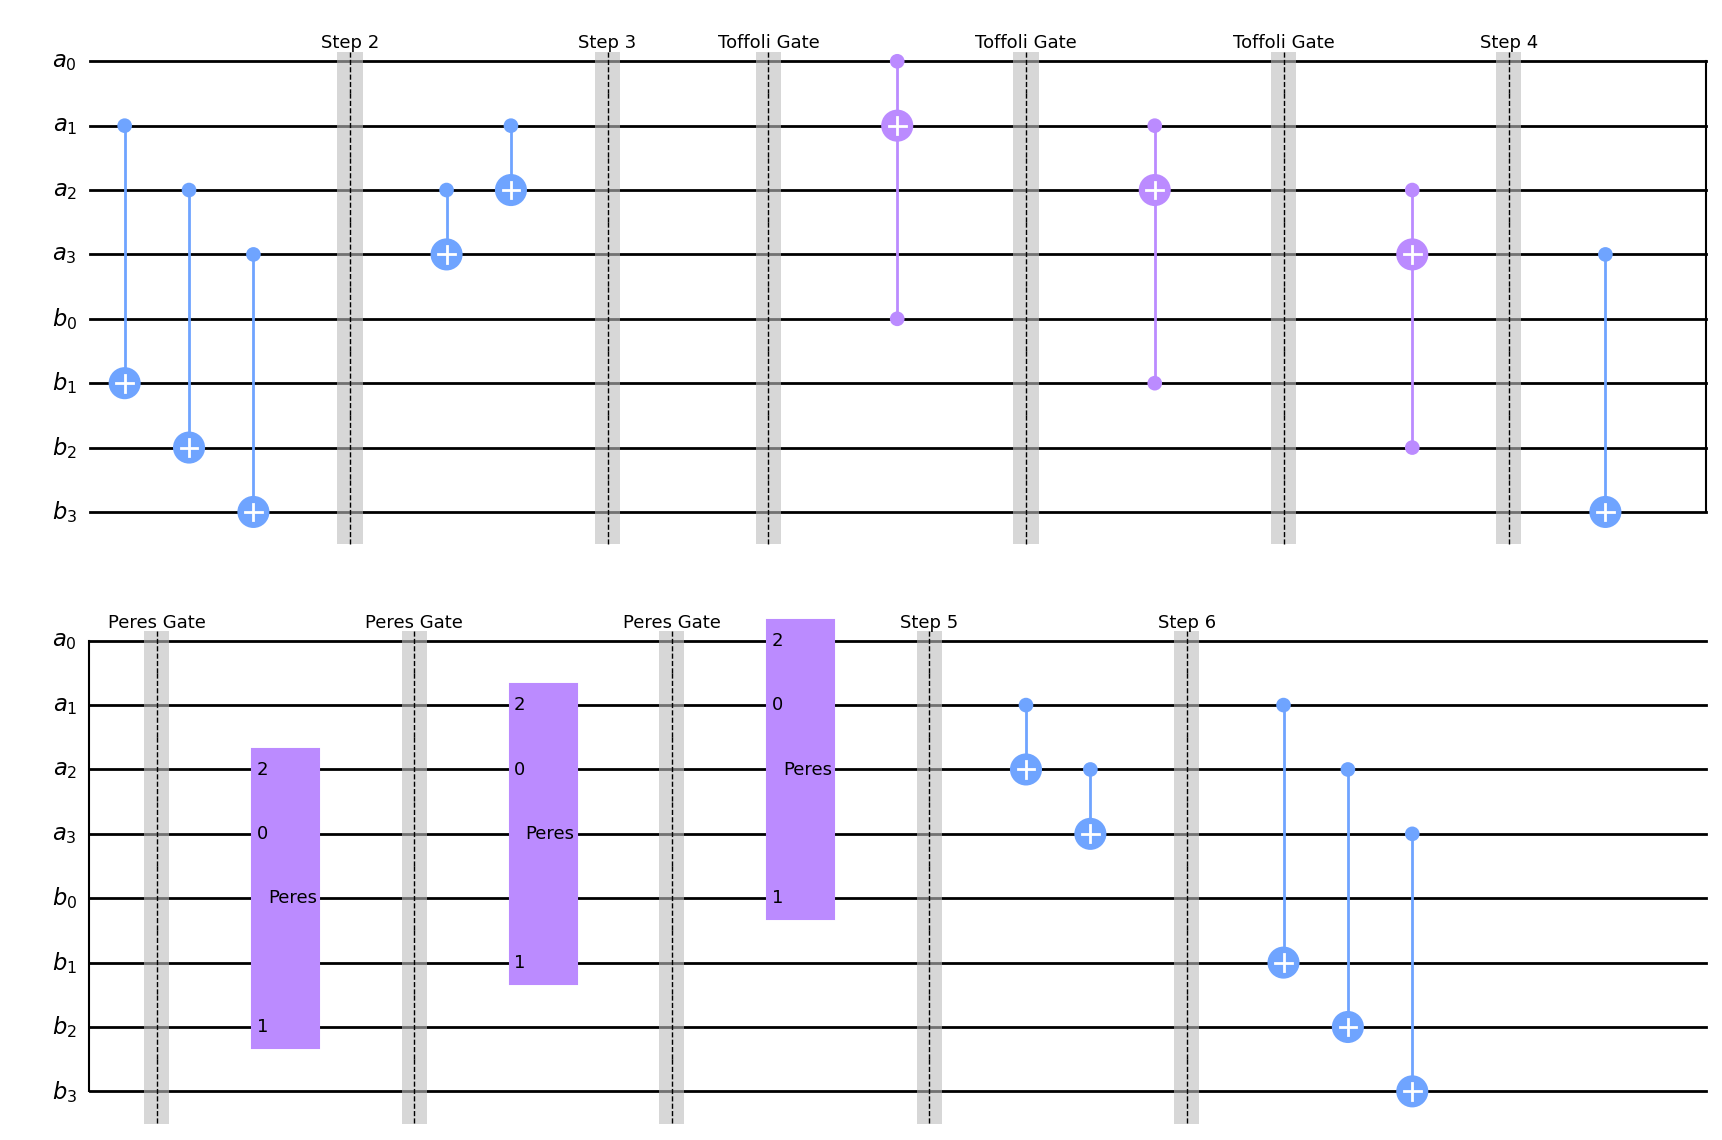

In [2]:
n = 4 # some arbitrary value
a = QuantumRegister(n, 'a') # "A" register
b = QuantumRegister(n, 'b') # "B" register

qc = QuantumCircuit(a, b)

basic_arithmetic_circuits.Addition_gate(qc, a, b, modular=True, useElementaryGates=False)

# get the unitary of the circuit
U = Operator(qc).data
#print("unitary operator: ", np.round(U, decimals=2))

# run inputs and print outputs
for b_val in range(int(2**n)):
    for a_val in range(int(2**n)):
        integer_input = b_val * int(2**n) + a_val
        state_vec = np.zeros(int(2**(2*n)))
        state_vec[integer_input] = 1
        input_state = Statevector(state_vec)

        # Apply the circuit to the state
        output_state = input_state.evolve(qc)
        integer_output = np.argmax(output_state.data)
        output_a = integer_output % int(2**n)
        output_b = integer_output // int(2**n)

        # Print as numpy array
        #print("input: ", state_vec, "   a = ", a_val, "   b = ", b_val)
        #print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a, "   b = ", output_b)

        if output_a != a_val:
            print("output a is not correct")
            print("input: ", state_vec, "   a = ", a_val, "   b = ", b_val)
            print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a, "   b = ", output_b)
            #raise Exception("output a is not correct")

        if output_b != (a_val + b_val) % int(2**n):
            print("output b is not correct")
            print("input: ", state_vec, "   a = ", a_val, "   b = ", b_val)
            print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a, "   b = ", output_b)
            #raise Exception("output b is not correct")

print(dict(qc.count_ops()))
qc.draw('mpl')

# Full Addition
$\ket{0} \ket{b}^{n} \ket{a}^n \rightarrow \ket{a+b}^{n+1} \ket{a}^n$

{'cx': 11, 'barrier': 11, 'unitary': 4, 'ccx': 3}


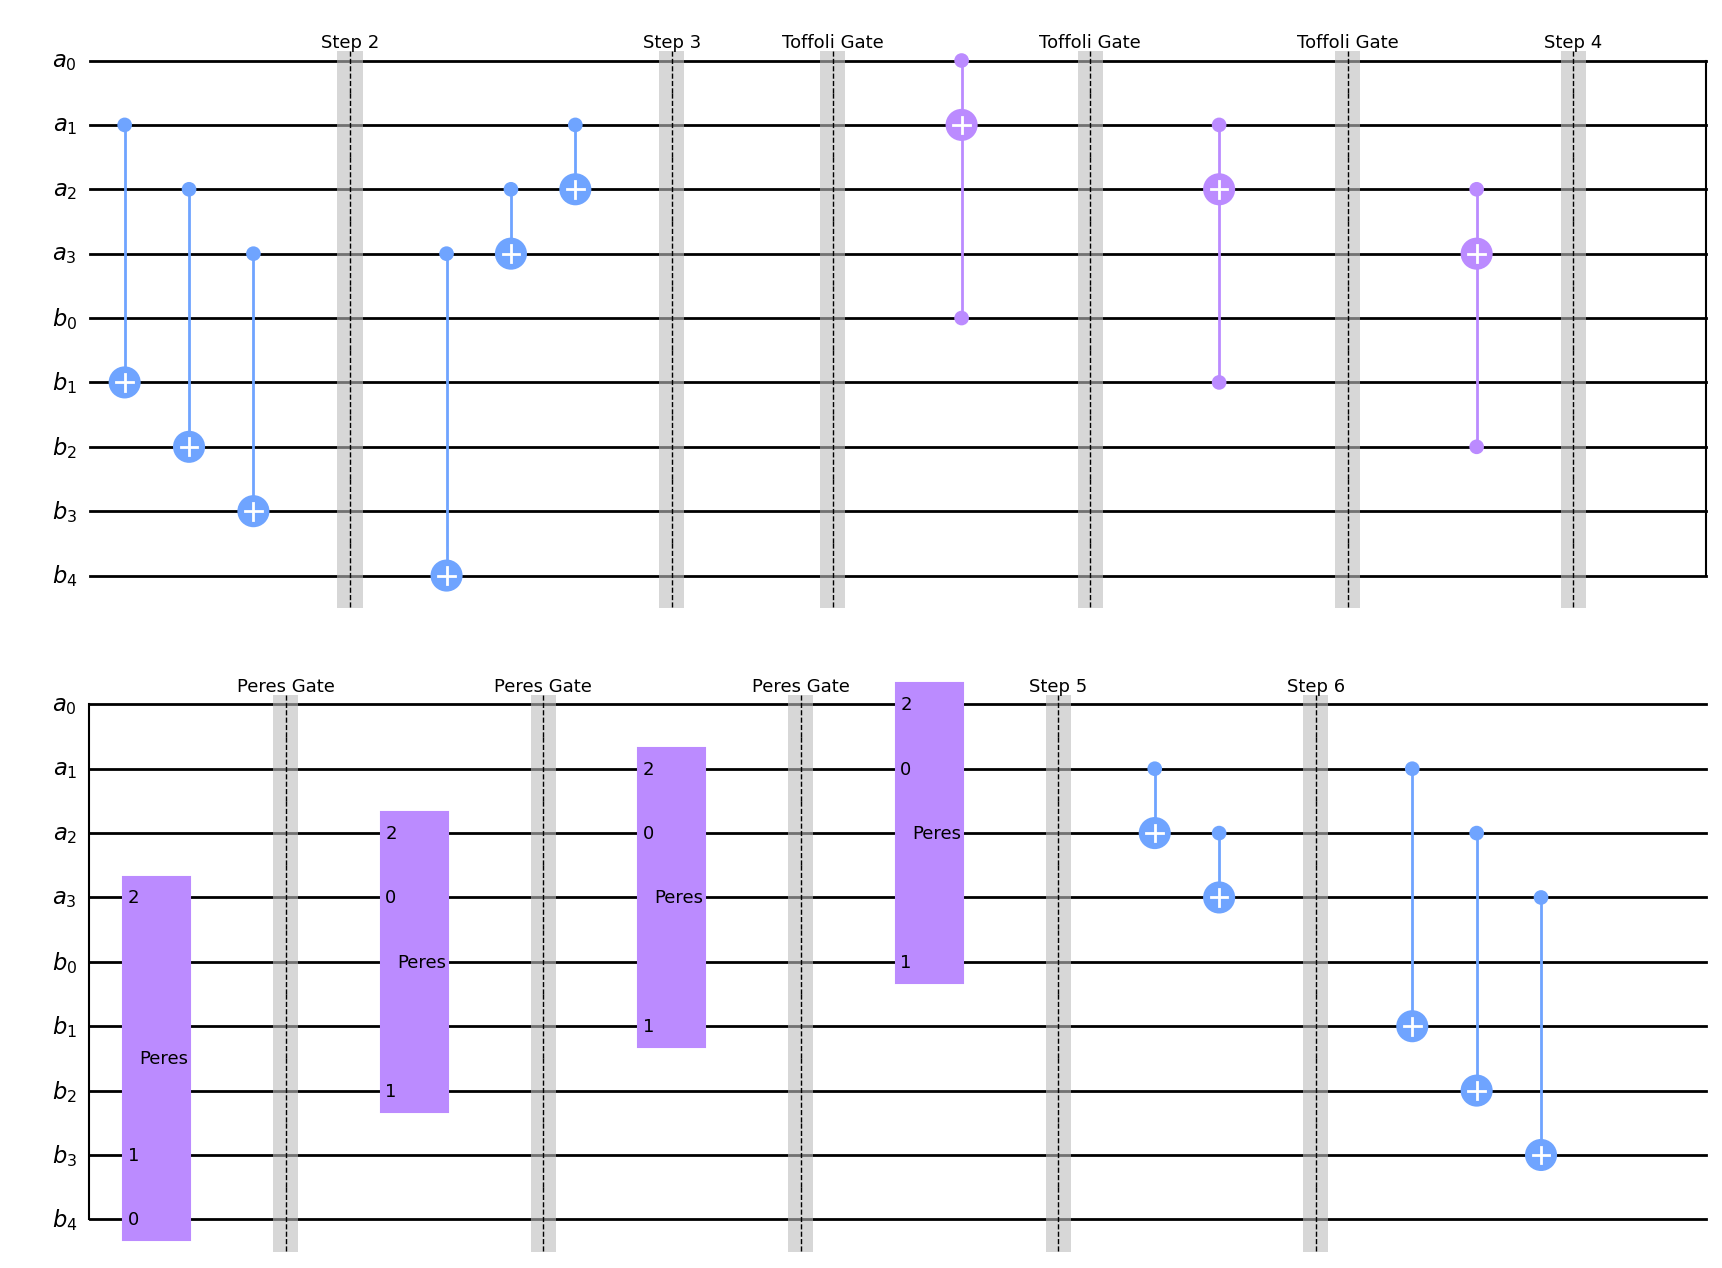

In [3]:
n = 4 # some arbitrary value
a = QuantumRegister(n, 'a') # "A" register
b = QuantumRegister(n+1, 'b') # "B" register

qc = QuantumCircuit(a, b)

basic_arithmetic_circuits.Addition_gate(qc, a, b, modular=False, useElementaryGates=False)

# get the unitary of the circuit
U = Operator(qc).data
#print("unitary operator: ", np.round(U, decimals=2))

# run inputs and print outputs
for b_val in range(int(2**n)):
    for a_val in range(int(2**n)):
        integer_input = b_val * int(2**n) + a_val
        state_vec = np.zeros(int(2**(2*n+1)))
        state_vec[integer_input] = 1
        input_state = Statevector(state_vec)

        # Apply the circuit to the state
        output_state = input_state.evolve(qc)
        integer_output = np.argmax(output_state.data)
        output_a = integer_output % int(2**n)
        output_b = integer_output // int(2**n)

        # Print as numpy array
        #print("input: ", state_vec, "   a = ", a_val, "   b = ", b_val)
        #print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a, "   b = ", output_b)

        if output_a != a_val:
            print("output a is not correct")
            print("input: ", state_vec, "   a = ", a_val, "   b = ", b_val)
            print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a, "   b = ", output_b)
            #raise Exception("output a is not correct")

        if output_b != (a_val + b_val) % int(2**(n+1)):
            print("output b is not correct")
            print("input: ", state_vec, "   a = ", a_val, "   b = ", b_val)
            print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a, "   b = ", output_b)
            #raise Exception("output b is not correct")

print(dict(qc.count_ops()))
qc.draw('mpl')

# 1s Complement
Taking some binary representation of an integer, apply the X gate to every qubit:

$\ket{a}^n \rightarrow \ket{2^n - a - 1}^n$

$\ket{a}^n = \ket{a_{n}} \ket{a_{n-1}} \ldots \ket{a_0} \rightarrow \ket{a_{n} \oplus 1} \ket{a_{n-1} \oplus 1} \ldots \ket{a_0 \oplus 1}$

{'x': 3}


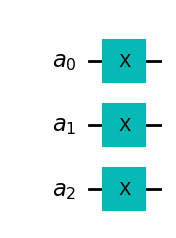

In [4]:
n = 3 # some arbitrary value
a = QuantumRegister(n, 'a') # "A" register

qc = QuantumCircuit(a)

basic_arithmetic_circuits.Ones_complement(qc, a)

# get the unitary of the circuit
U = Operator(qc).data
#print("unitary operator: ", np.round(U, decimals=2))

# run inputs and print outputs
for a_val in range(int(2**n)):
    integer_input = a_val
    state_vec = np.zeros(int(2**n))
    state_vec[integer_input] = 1
    input_state = Statevector(state_vec)

    # Apply the circuit to the state
    output_state = input_state.evolve(qc)
    output_a = np.argmax(output_state.data)

    if output_a != int(2**n) - a_val - 1:
        print("output a is not correct")
        print("input: ", state_vec, "   a = ", a_val)
        print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a)
        #raise Exception("output a is not correct")


print(dict(qc.count_ops()))
qc.draw('mpl')

# Integer Multiplication

This section implements the shift-and-add construction from Muñoz-Coreas and Thapliyal, *Quantum Circuit Design of a T-count Optimized Integer Multiplier* ([arXiv:1706.05113](https://arxiv.org/abs/1706.05113)). For two $n$-bit inputs, the circuit maps

$$|a\rangle|b\rangle|0\rangle^{\otimes(2n+1)} \longrightarrow |a\rangle|b\rangle|a b\rangle|0\rangle.$$

The first partial product is generated with a Toffoli array. Each later bit of $b$ controls the paper's seven-step conditional ripple-carry adder on a shifted slice of the product register. The final product occupies `p[0:2*n]`; `p[2*n]` is restored to zero.

All 64 products for 3-bit inputs passed.
{'ccx': 25, 'cx': 12}


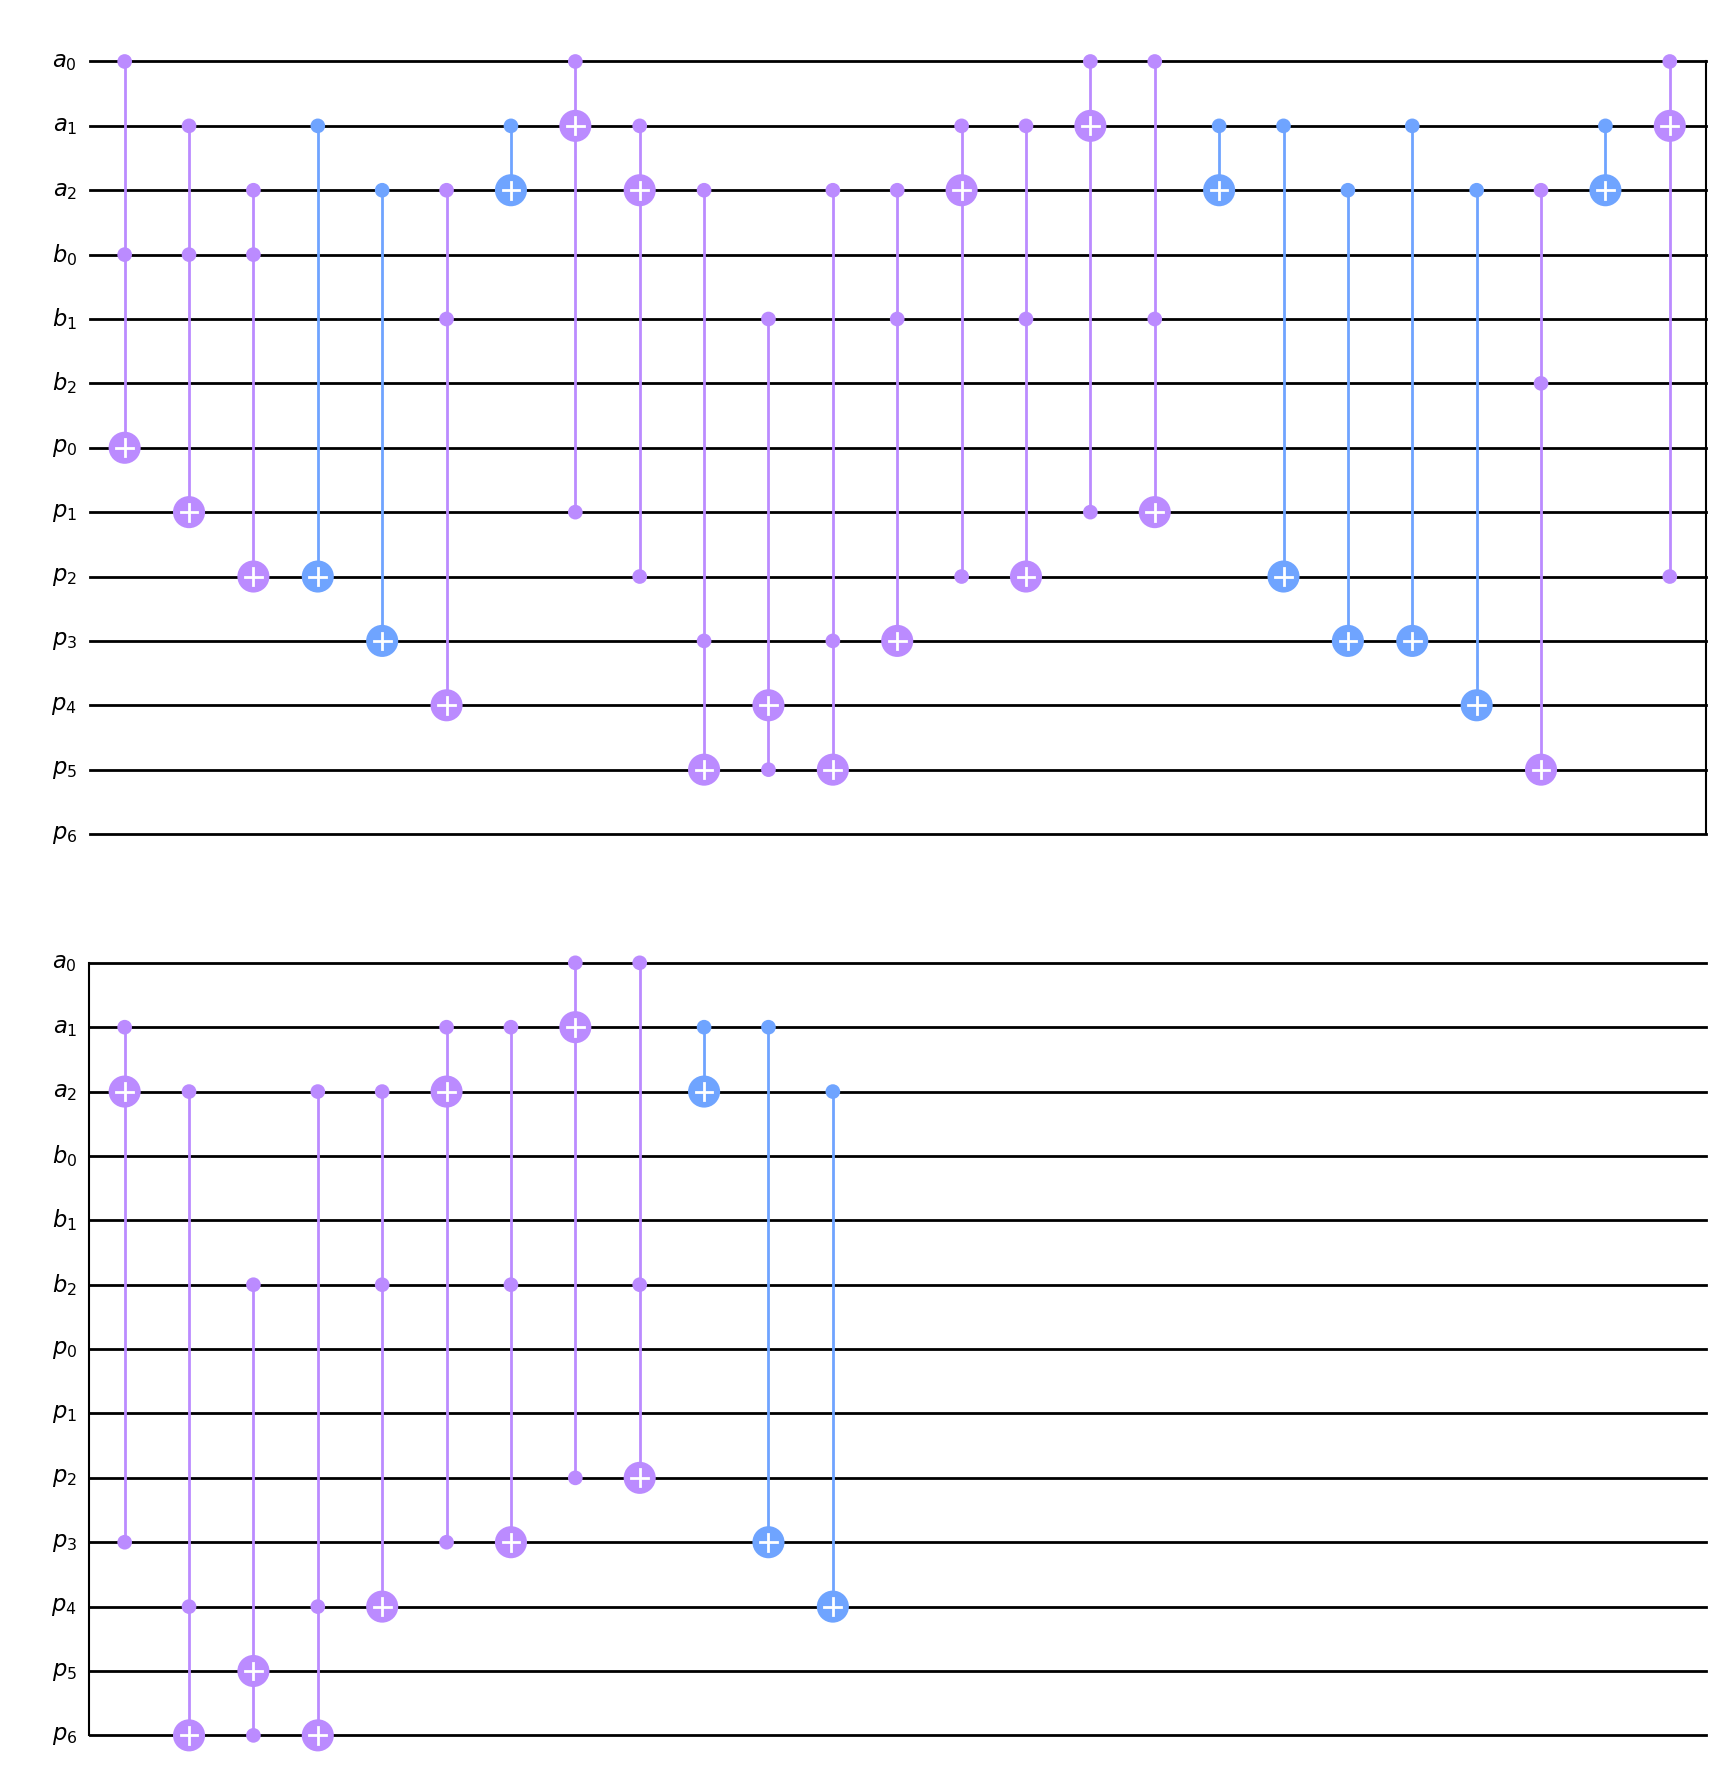

In [5]:
n = 3
a = QuantumRegister(n, 'a')
b = QuantumRegister(n, 'b')
p = QuantumRegister(2*n + 1, 'p')

qc = QuantumCircuit(a, b, p)
basic_arithmetic_circuits.Integer_multiplication_gate(qc, a, b, p, useElementaryGates=False)

# Exhaustively test all pairs of unsigned n-bit integers.
input_mask = 2**n - 1
product_mask = 2**(2*n) - 1
for a_val in range(2**n):
    for b_val in range(2**n):
        integer_input = a_val | (b_val << n)  # p starts in |0...0>
        input_state = Statevector.from_int(integer_input, dims=2**qc.num_qubits)
        output_state = input_state.evolve(qc)
        integer_output = int(np.argmax(np.abs(output_state.data)))

        output_a = integer_output & input_mask
        output_b = (integer_output >> n) & input_mask
        output_p = (integer_output >> (2*n)) & product_mask
        output_work = integer_output >> (4*n)

        assert output_a == a_val, f"a was not preserved for {a_val} * {b_val}"
        assert output_b == b_val, f"b was not preserved for {a_val} * {b_val}"
        assert output_p == a_val * b_val, (
            f"incorrect product for {a_val} * {b_val}: got {output_p}"
        )
        assert output_work == 0, f"work qubit was not cleared for {a_val} * {b_val}"

print(f"All {2**(2*n)} products for {n}-bit inputs passed.")
print(dict(qc.count_ops()))
qc.draw('mpl')
